In [1]:
import os

In [2]:
from typing_extensions import TypedDict

In [3]:
class State(TypedDict):
    graph_state:str

In [4]:
def first_node(state):
    print("This is my first node, which as as template")
    return {"graph_state":state['graph_state']+"This is first template"}


def second_node(state):
    print("My second node is called")
    return{"graph_state":state["graph_state"]+"This is the second template"}



In [5]:
from typing import Literal

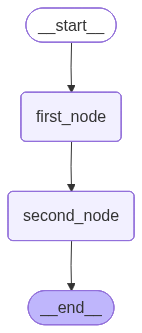

In [8]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

builder=StateGraph(State)
builder.add_node("first_node",first_node)
builder.add_node("second_node",second_node)

builder.add_edge(START,"first_node")
builder.add_edge("first_node","second_node")
builder.add_edge("second_node",END)

graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
graph.invoke({"graph_state":"Hi, my name is prem, "})

This is my first node, which as as template
My second node is called


{'graph_state': 'Hi, my name is prem, This is first templateThis is the second template'}

## Dynamic Linear Workflow

In [26]:
def create_node(text:str):
    def node(state):
        return{
            "graph_state":state.get("graph_state"," ")+ f"{text} "
        }
    return node

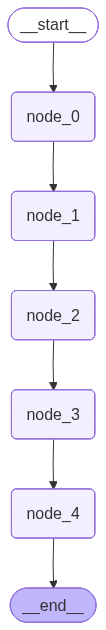

In [27]:
from langgraph.graph import StateGraph,END

#define state
class GraphState(TypedDict):
    graph_state:str

builder=StateGraph(GraphState)



#Dynamic inputs
steps=['hello','this','is','dynamic','graph']

#Create nodes dynamically

for i , step in enumerate(steps):
    node_name=f"node_{i}"
    builder.add_node(node_name,create_node(step))
    
    
#connect nodes dynamically
for i in range(len(steps)-1):
    builder.add_edge(f"node_{i}",f"node_{i+1}")
    
# Entry + end
builder.set_entry_point("node_0")
builder.add_edge(f"node_{len(steps)-1}",END)

graphs=builder.compile()

display(Image(graphs.get_graph().draw_mermaid_png()))

In [28]:
result=graphs.invoke({})
print(result)

{'graph_state': ' hello this is dynamic graph '}


## Dynamic Chain method

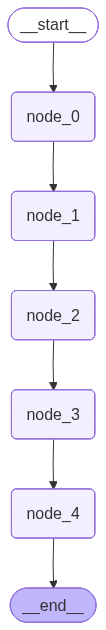

None


In [36]:
from langgraph.graph import StateGraph,END

class GraphState(TypedDict):
    graph_state:str

# class GraphState(dict):
#     pass
    
def create_node(step):
    def node(state:GraphState):
        history=state.get("history",[])
        history.append(step.upper())
        return{"history":history}
    return node

builder=StateGraph(GraphState)


steps=['hello','this','is','dynamic','graph']

#create node
for i, step in enumerate(steps):
    builder.add_node(f"node_{i}",create_node(step))
    
#connect nodes
for i in range(len(steps)-1):
    builder.add_edge(f"node_{i}",f"node_{i+1}")
    
builder.set_entry_point("node_0")
builder.add_edge(f"node_{len(steps)-1}",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


result=graph.invoke({})
print(result)
    

## Dynamic Router (branching logic)

In [38]:
def router(state: GraphState):
    text = " ".join(state.get("history", []))
    
    if "ERROR" in text:
        return "error_node"
    else:
        return "success_node"

def error_node(state):
    return {"result": "Something went wrong"}

def success_node(state):
    return {"result": "All good: " + " ".join(state["history"])}

builder = StateGraph(GraphState)

# reuse dynamic nodes
for i, step in enumerate(steps):
    builder.add_node(f"node_{i}", create_node(step))

builder.add_node("router", router)
builder.add_node("error_node", error_node)
builder.add_node("success_node", success_node)

# connect linear flow → router
for i in range(len(steps) - 1):
    builder.add_edge(f"node_{i}", f"node_{i+1}")

builder.add_edge(f"node_{len(steps)-1}", "router")

# conditional edges
builder.add_conditional_edges(
    "router",
    router,
    {
        "error_node": "error_node",
        "success_node": "success_node"
    }
)

builder.set_entry_point("node_0")
builder.add_edge("error_node", END)
builder.add_edge("success_node", END)

graph = builder.compile()

## Dynamic Loop + Retry (Agent-like behavior)

In [40]:
def process_node(state):
    count = state.get("count", 0)
    return {"count": count + 1}

def check_node(state):
    if state["count"] < 3:
        return "retry"
    else:
        return "done"

builder = StateGraph(GraphState)

builder.add_node("process", process_node)
builder.add_node("check", check_node)

# loop structure
builder.add_edge("process", "check")

builder.add_conditional_edges(
    "check",
    check_node,
    {
        "retry": "process",   # loop back
        "done": END
    }
)

builder.set_entry_point("process")

graph = builder.compile()


In [ ]:

print(graph.invoke({"count": 0}))